<h1 style="text-align: center; background-color:#ff5ccd; color: white; font-size: 60px; padding: 50px;"> BREAST CANCER PREDICTION </h1>

## --------------------------------------------------------------------------------------------------------------

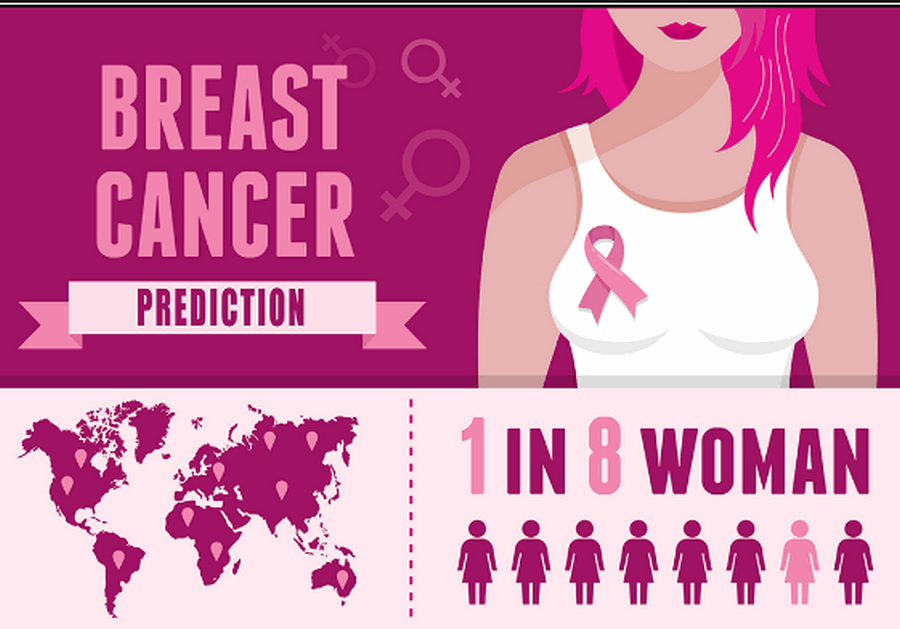

## --------------------------------------------------------------------------------------------------------------

## 
Breast cancer is the most common cancer amongst women in the world. It accounts for 25% of all cancer cases and affected over 2.1 Million people in 2015 alone. It starts when cells in the breast begin to grow out of control. These cells usually form tumors that can be seen via X-ray or felt as lumps in the breast area.






Breast cancer is cancer that forms in the cells of the breasts.

It arises in the lining cells (epithelium) of the ducts (85%) or lobules (15%) in the glandular tissue of the breast. Initially, the cancerous growth is confined to the duct or lobule (“in situ”) where it generally causes no symptoms and has minimal potential for spread (metastasis).

Most types of breast cancer are easy to diagnose by microscopic analysis of a sample - or biopsy - of the affected area of the breast. Also, there are types of breast cancer that require specialized lab exams.

## --------------------------------------------------------------------------------------------------------------

### 1.Import the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import warnings
warnings.filterwarnings("ignore")

### 2. Load the dataset

In [2]:
data=pd.read_csv(r"C:\Users\vaibh\Downloads\data.csv")  # reading data into the dataframe
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 3.EDA

In [3]:
data.info()    # concise summary of dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [5]:
data.columns.values  # describing column names

array(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean',
       'concavity_mean', 'concave points_mean', 'symmetry_mean',
       'fractal_dimension_mean', 'radius_se', 'texture_se',
       'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se',
       'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype=object)

In [6]:
data.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [7]:
data2=data.copy()    # making copy of data

In [8]:
data.drop(columns=["id"],axis=1,inplace=True)  # dropping id column

In [9]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
data.drop("Unnamed: 32", axis=1, inplace=True)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 4.Data Visualization

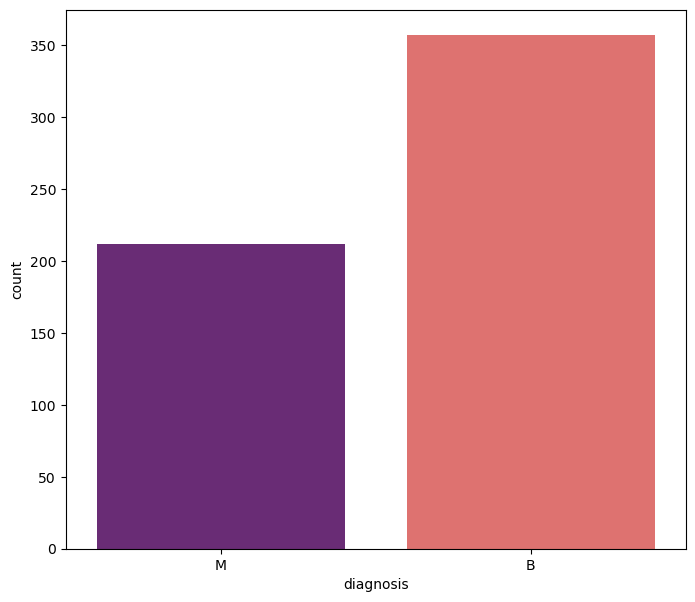

In [11]:
plt.figure(figsize = (8,7))
sns.countplot(x="diagnosis", data=data, palette='magma')
plt.show()

In [12]:
# Getting Mean Columns with diagnosis
m_col = ['diagnosis','radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

# Getting Se Columns with diagnosis
s_col = ['diagnosis','radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se']

# Getting Worst column with diagnosis
w_col = ['diagnosis','radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst']

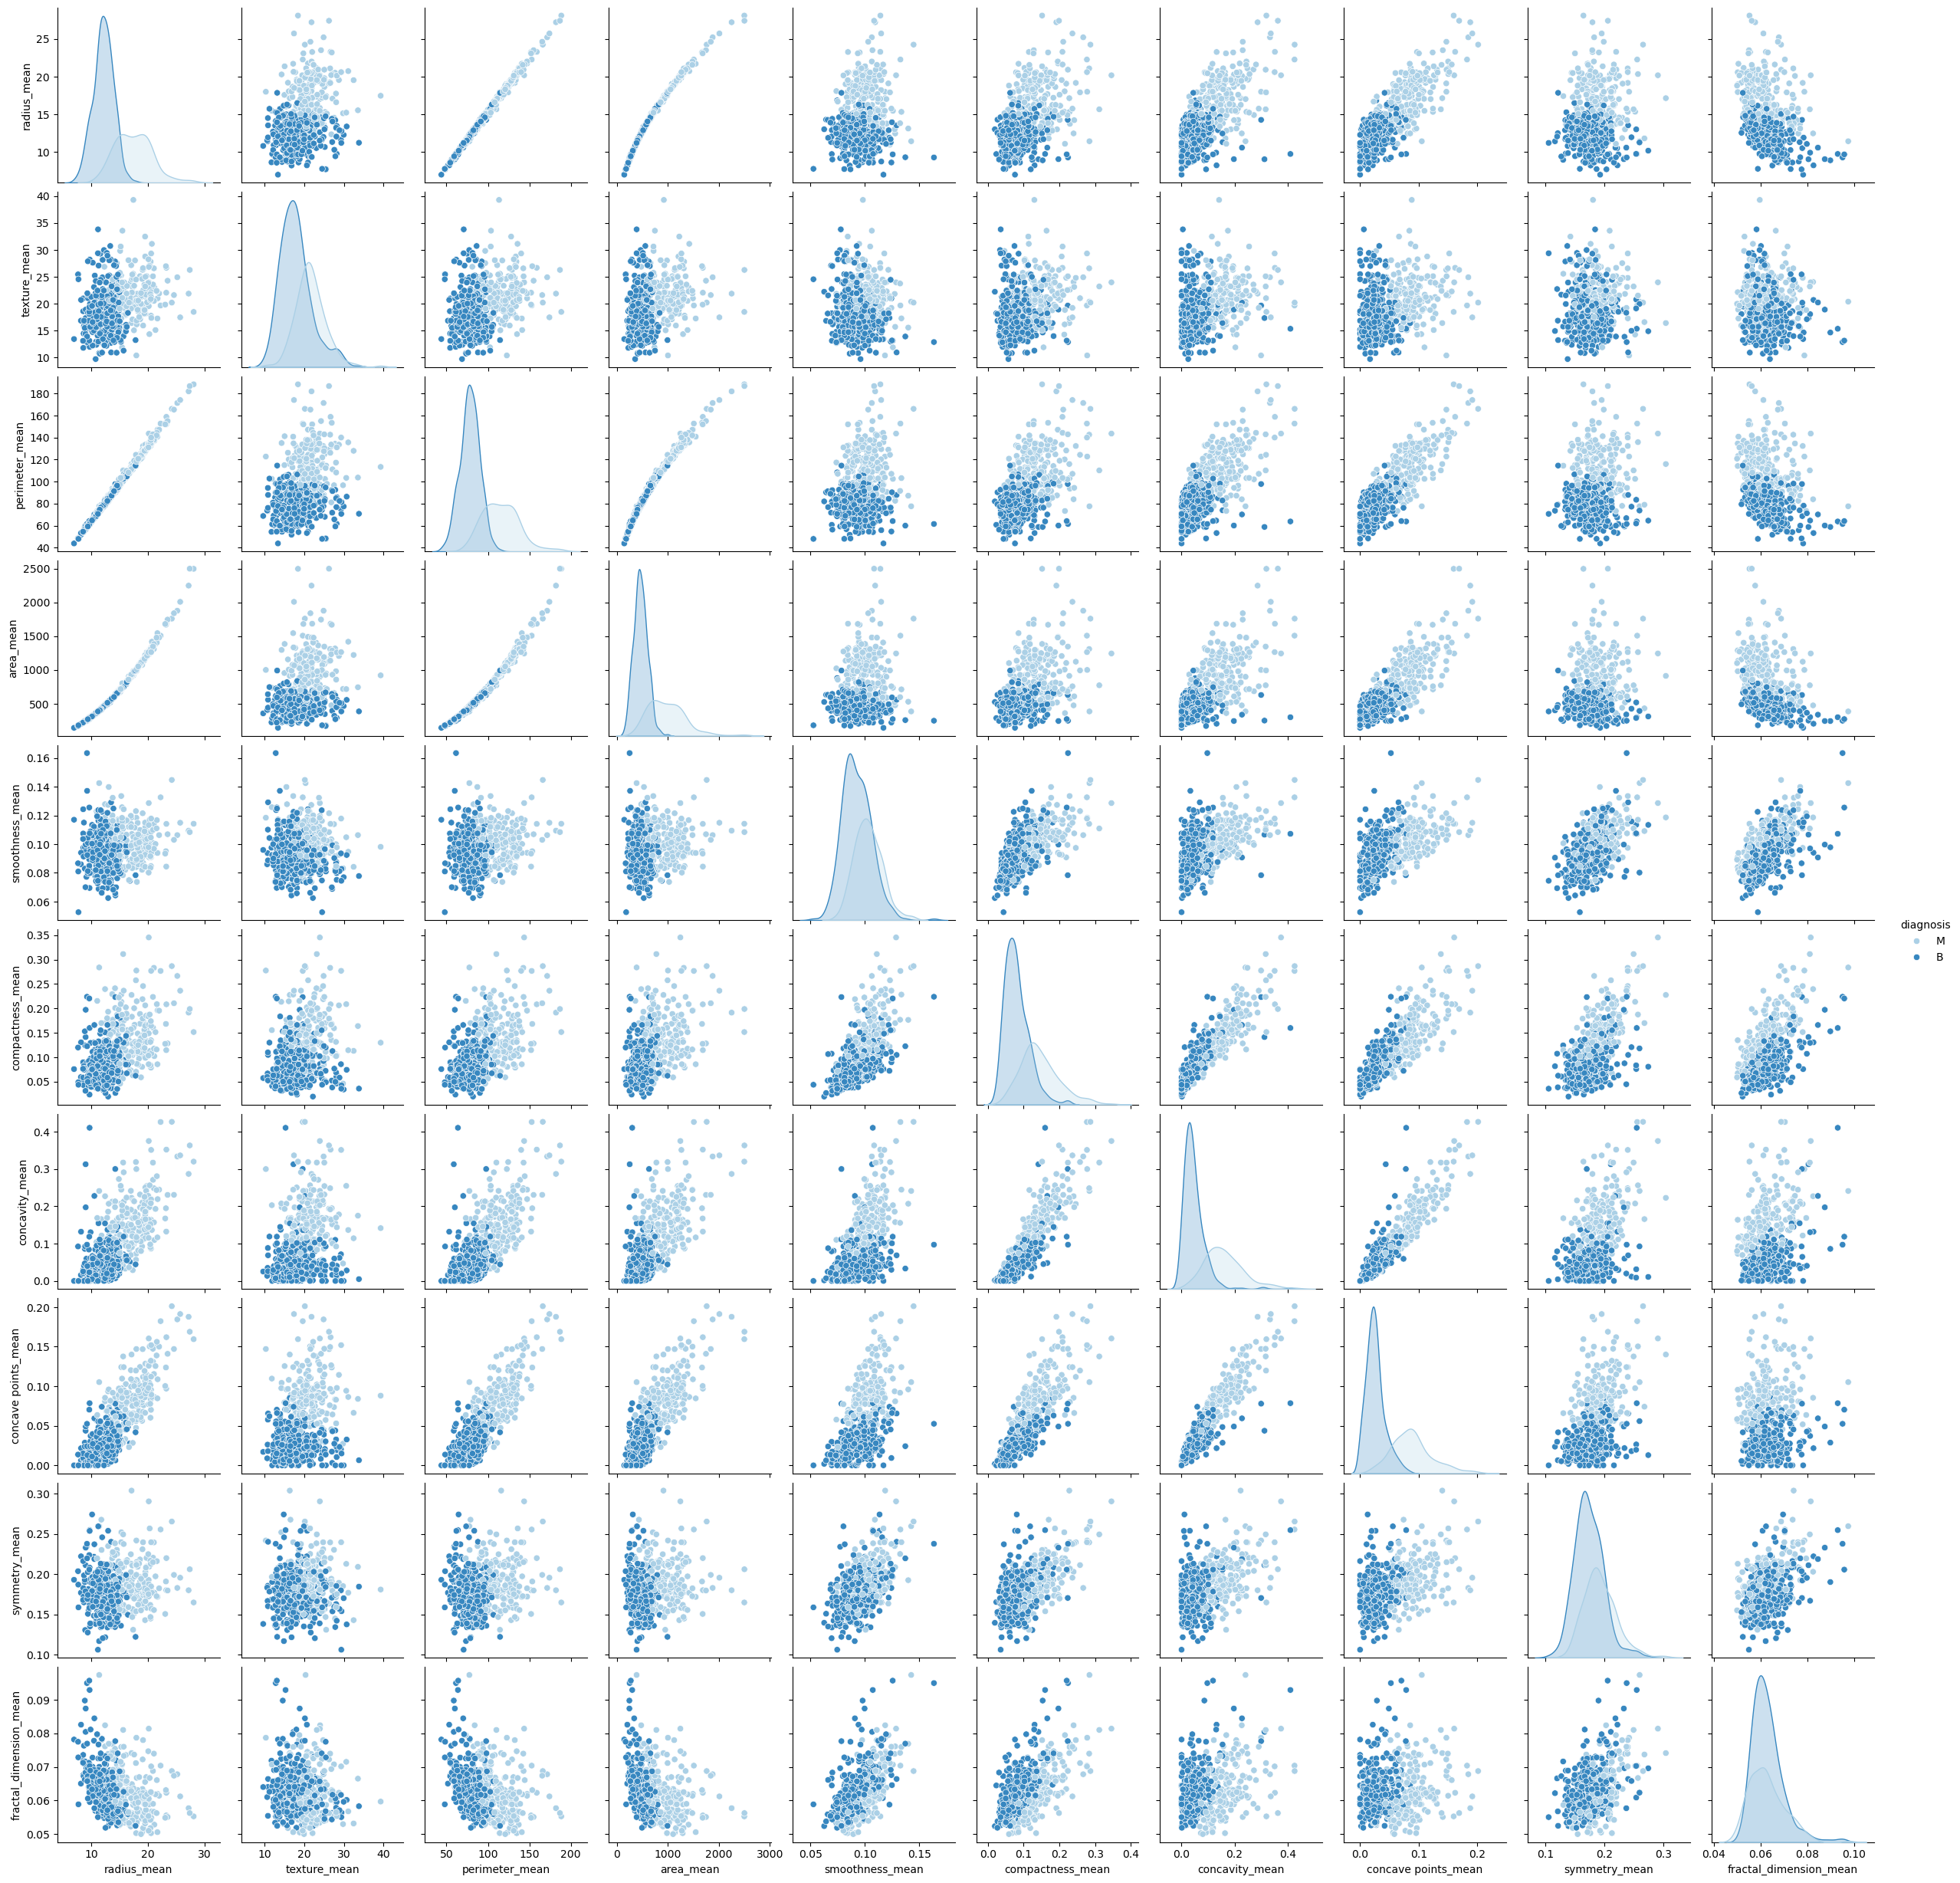

In [13]:
# pairplot for mean columns
sns.pairplot(data[m_col],hue = 'diagnosis', palette='Blues')
plt.show()

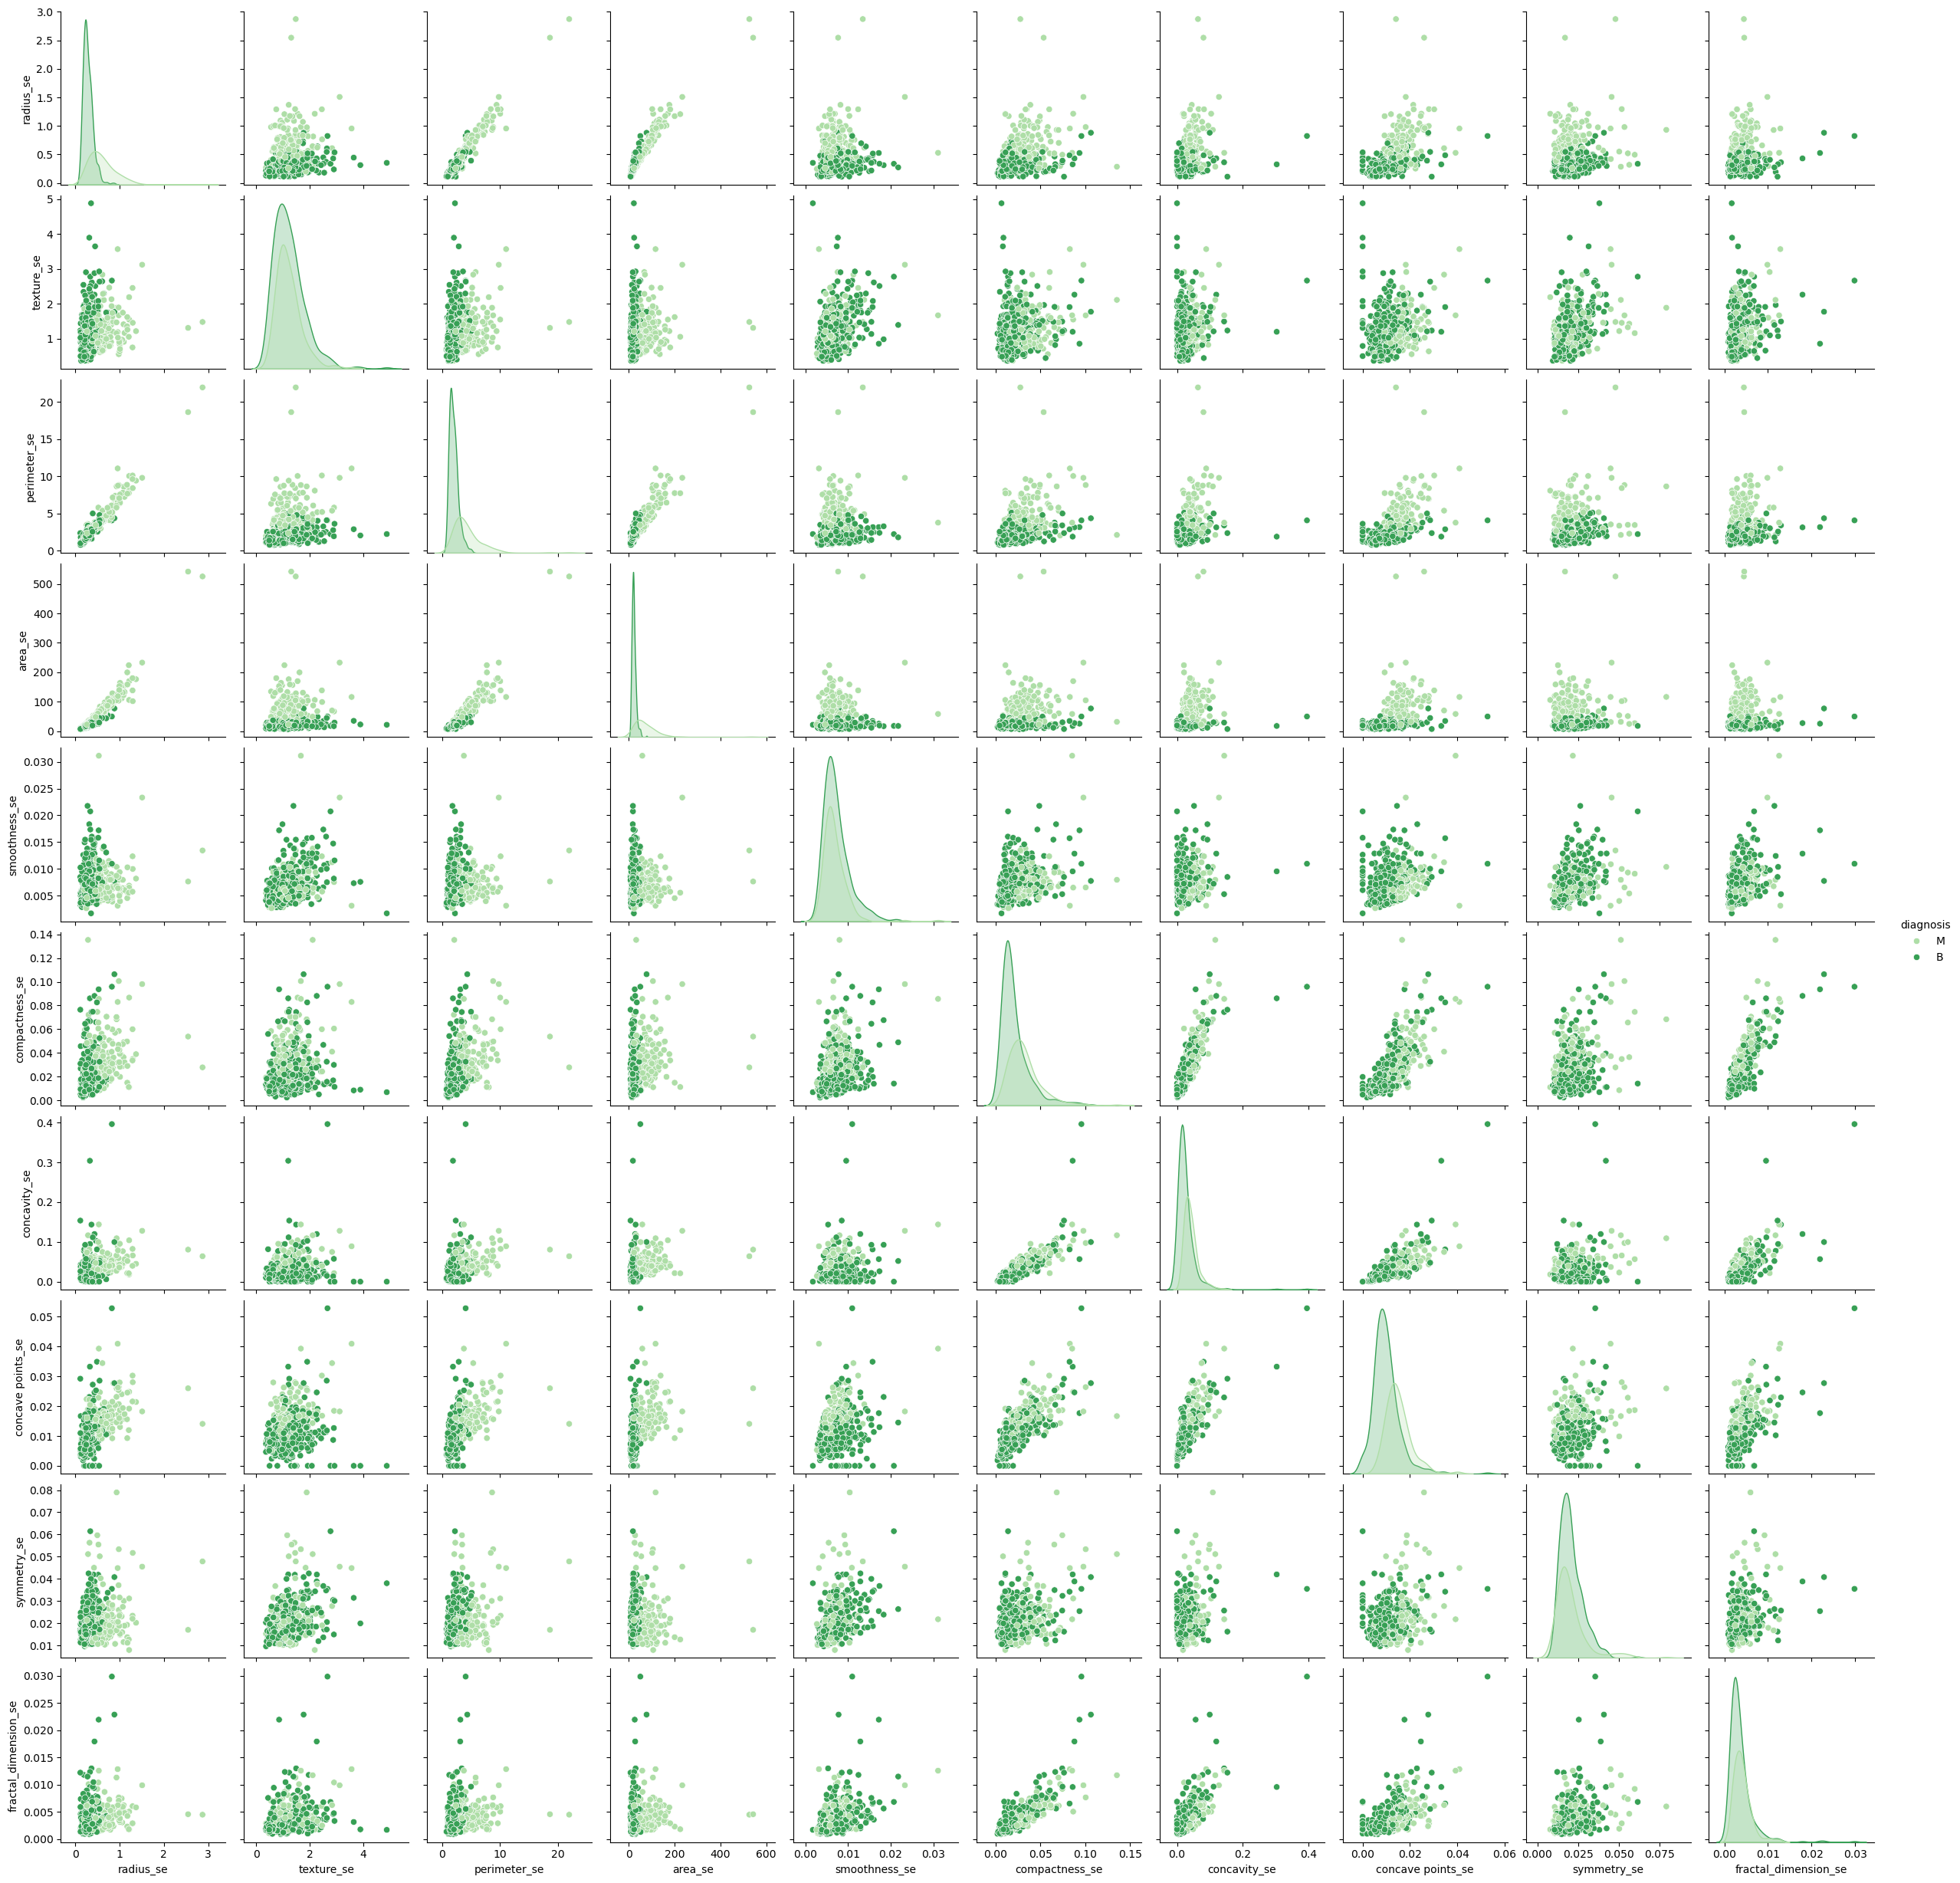

In [14]:
# pairplot for se columns
sns.pairplot(data[s_col],hue = 'diagnosis', palette='Greens')
plt.show()

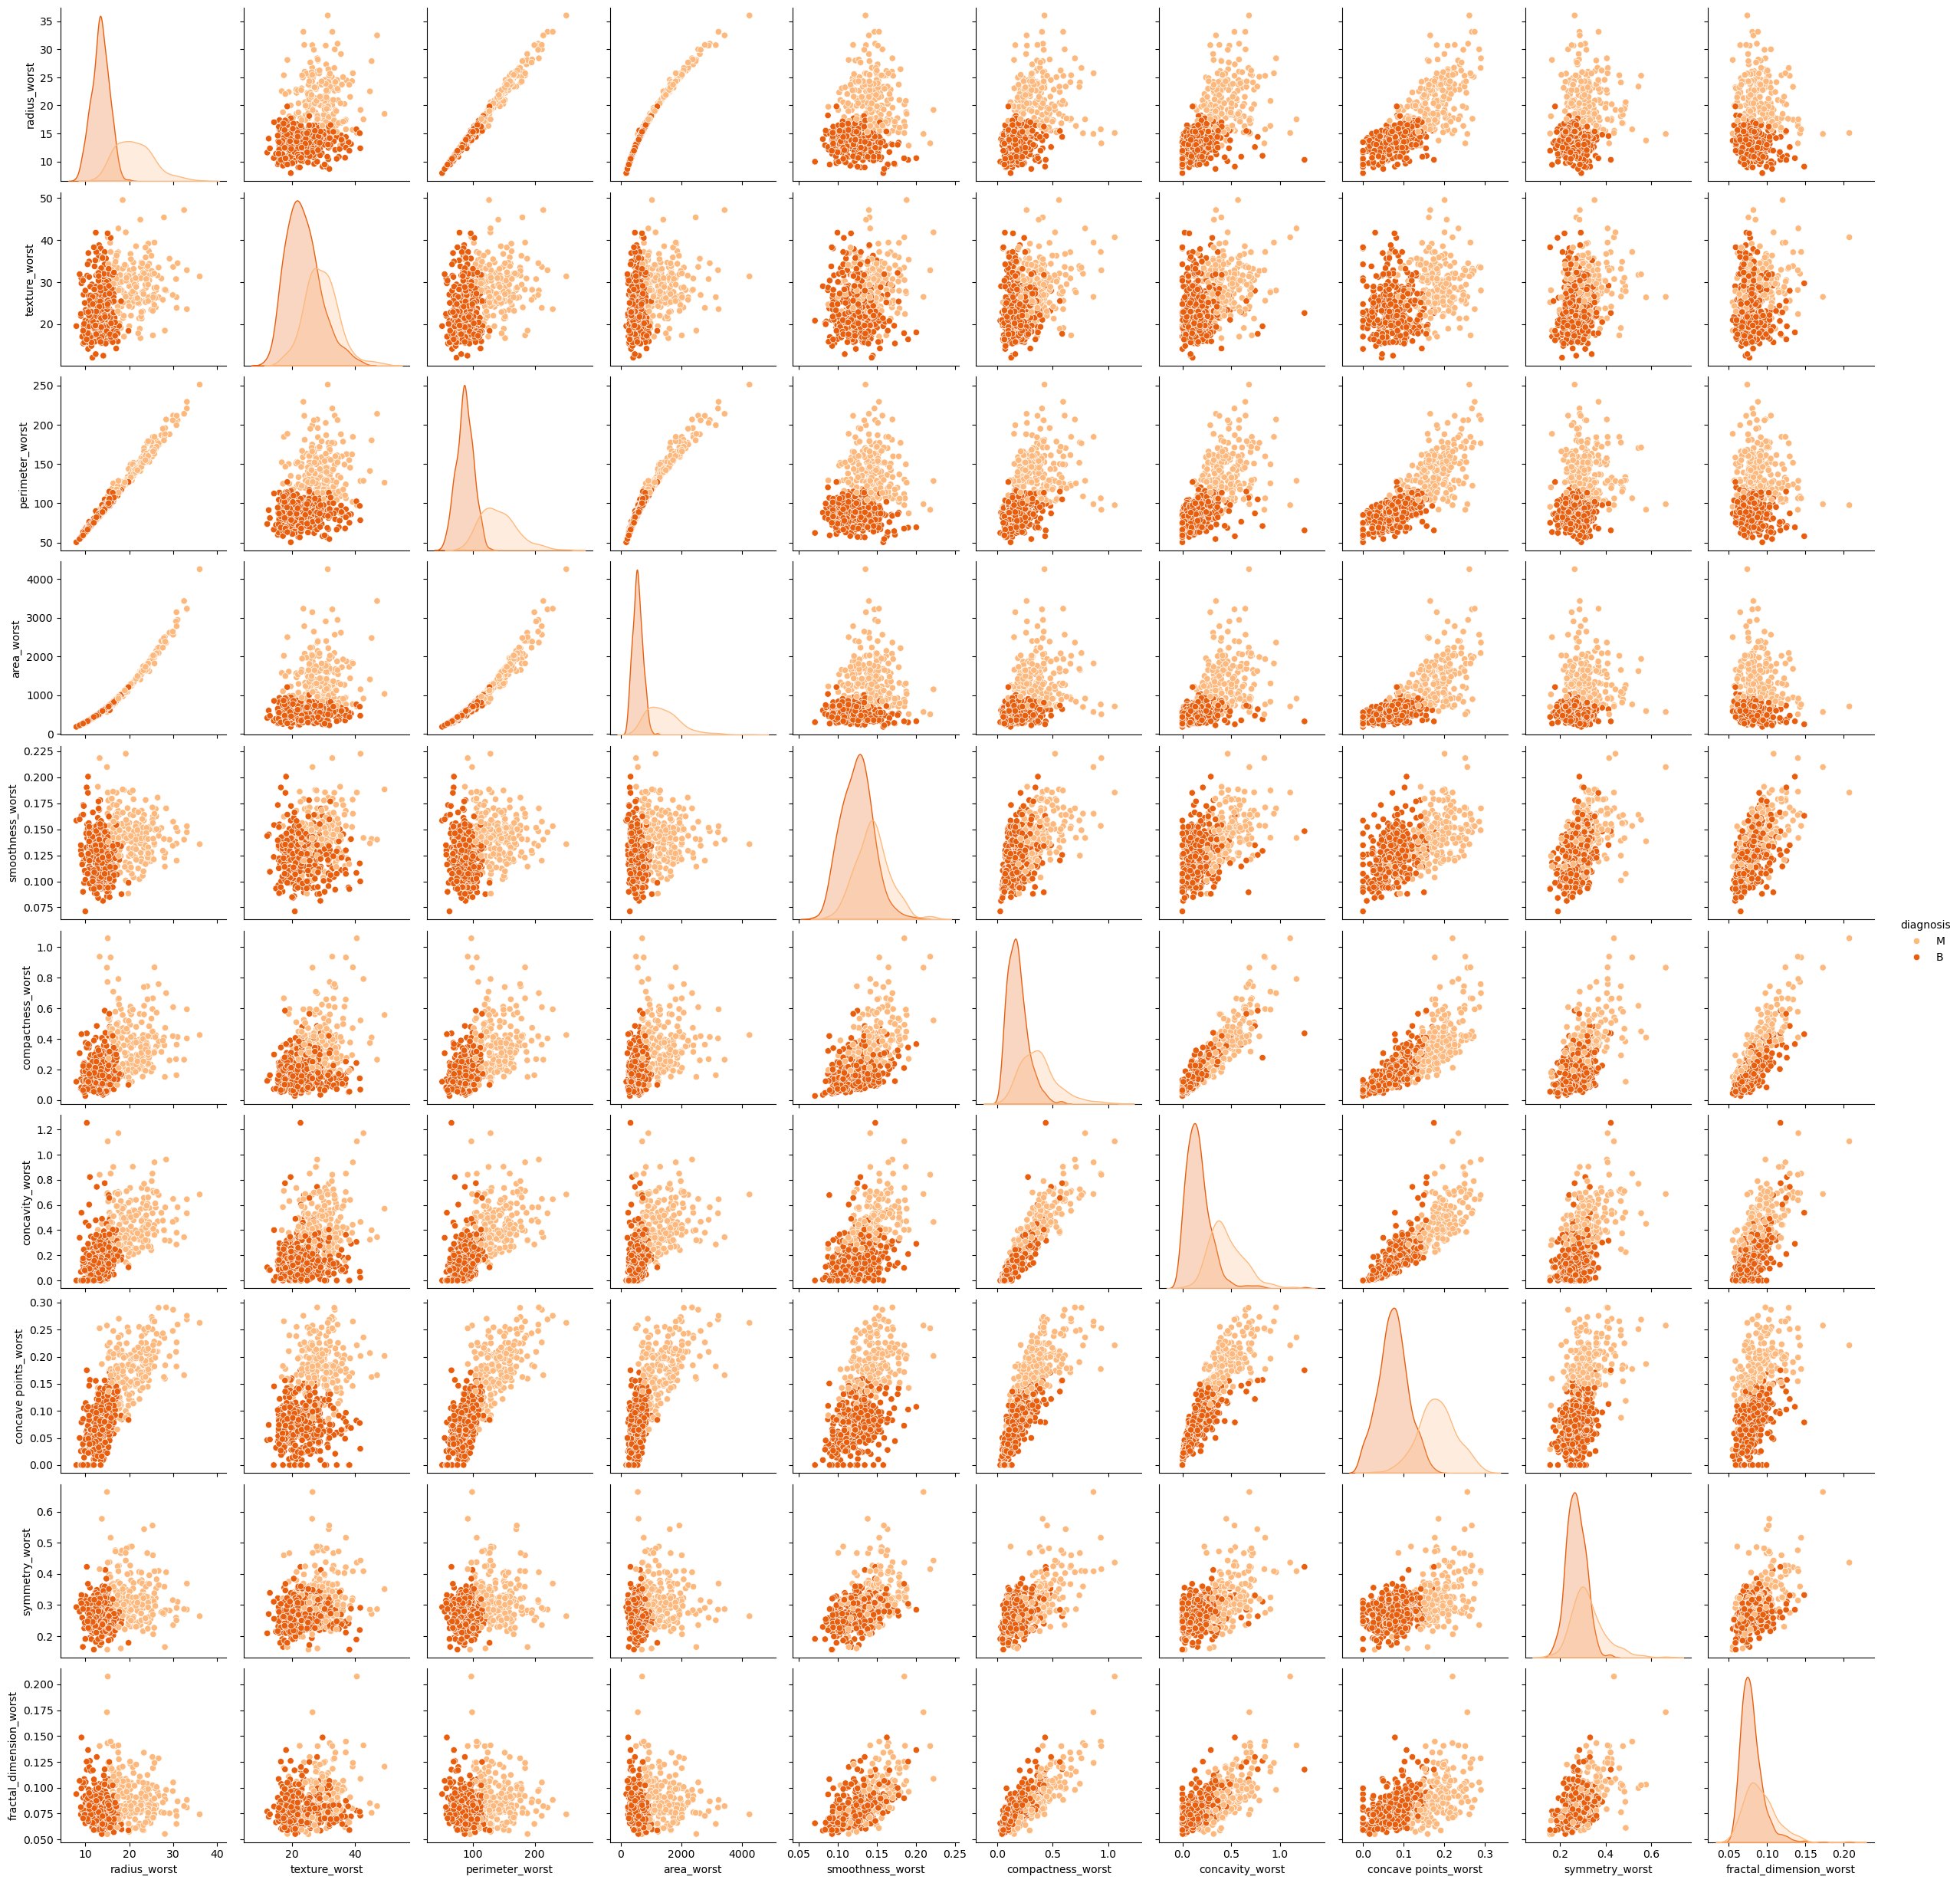

In [15]:
# pairplot for worst columns
sns.pairplot(data[w_col],hue = 'diagnosis', palette='Oranges')
plt.show()

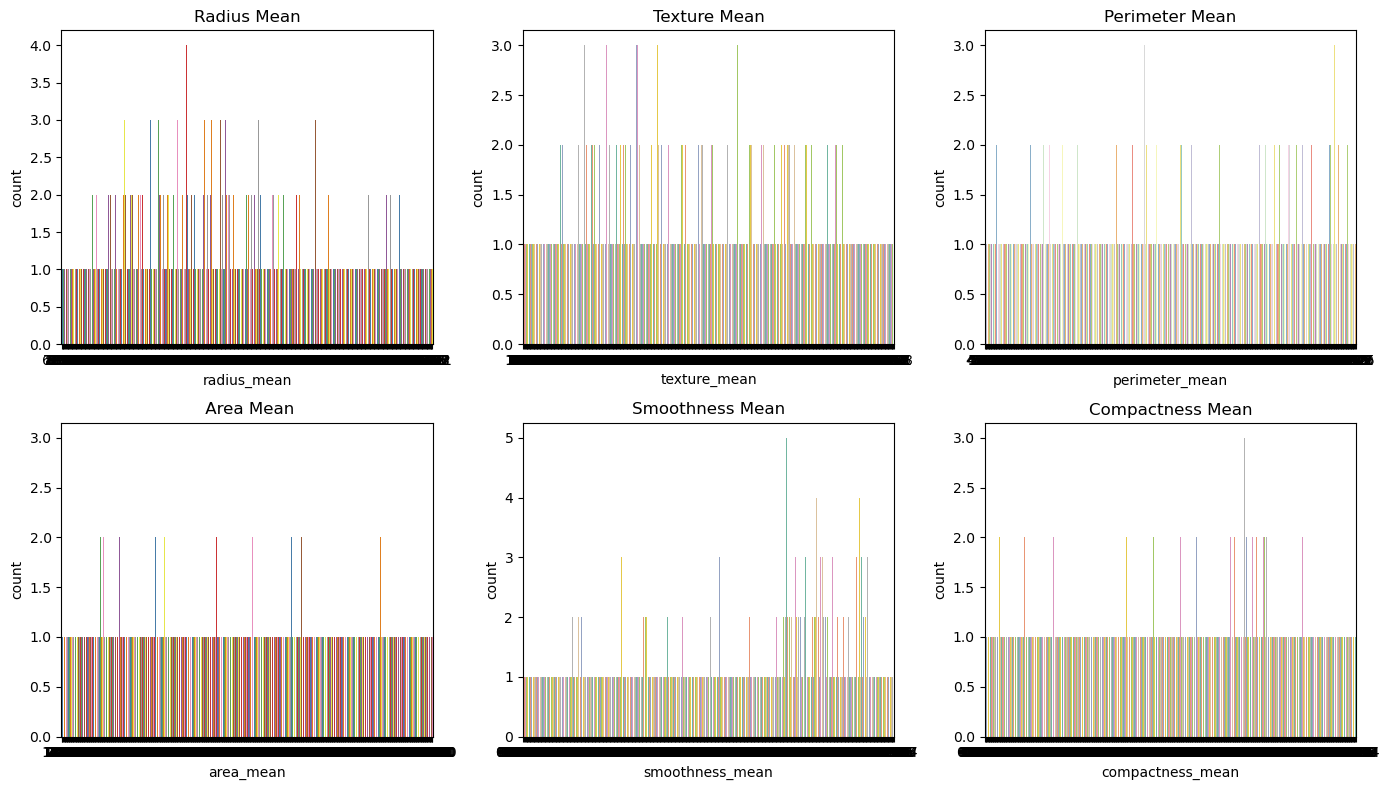

In [16]:
plt.figure(figsize=(14, 8))



plt.subplot(2, 3, 1)
sns.countplot(x='radius_mean', data=data, palette='Set1')
plt.title('Radius Mean')

plt.subplot(2, 3, 2)
sns.countplot(x='texture_mean', data=data, palette='Set2')
plt.title('Texture Mean')

plt.subplot(2, 3, 3)
sns.countplot(x='perimeter_mean', data=data, palette='Set3')
plt.title('Perimeter Mean')

plt.subplot(2, 3, 4)
sns.countplot(x='area_mean', data=data, palette='Set1')
plt.title(' Area Mean')

plt.subplot(2, 3, 5)
sns.countplot(x='smoothness_mean', data=data, palette='Set2')
plt.title('Smoothness Mean')

plt.subplot(2, 3, 6)
sns.countplot(x='compactness_mean', data=data, palette='Set2')
plt.title('Compactness Mean')

plt.tight_layout()
# plt.tight_layout(): Ensures plots don’t overlap and are evenly spaced.
plt.show()

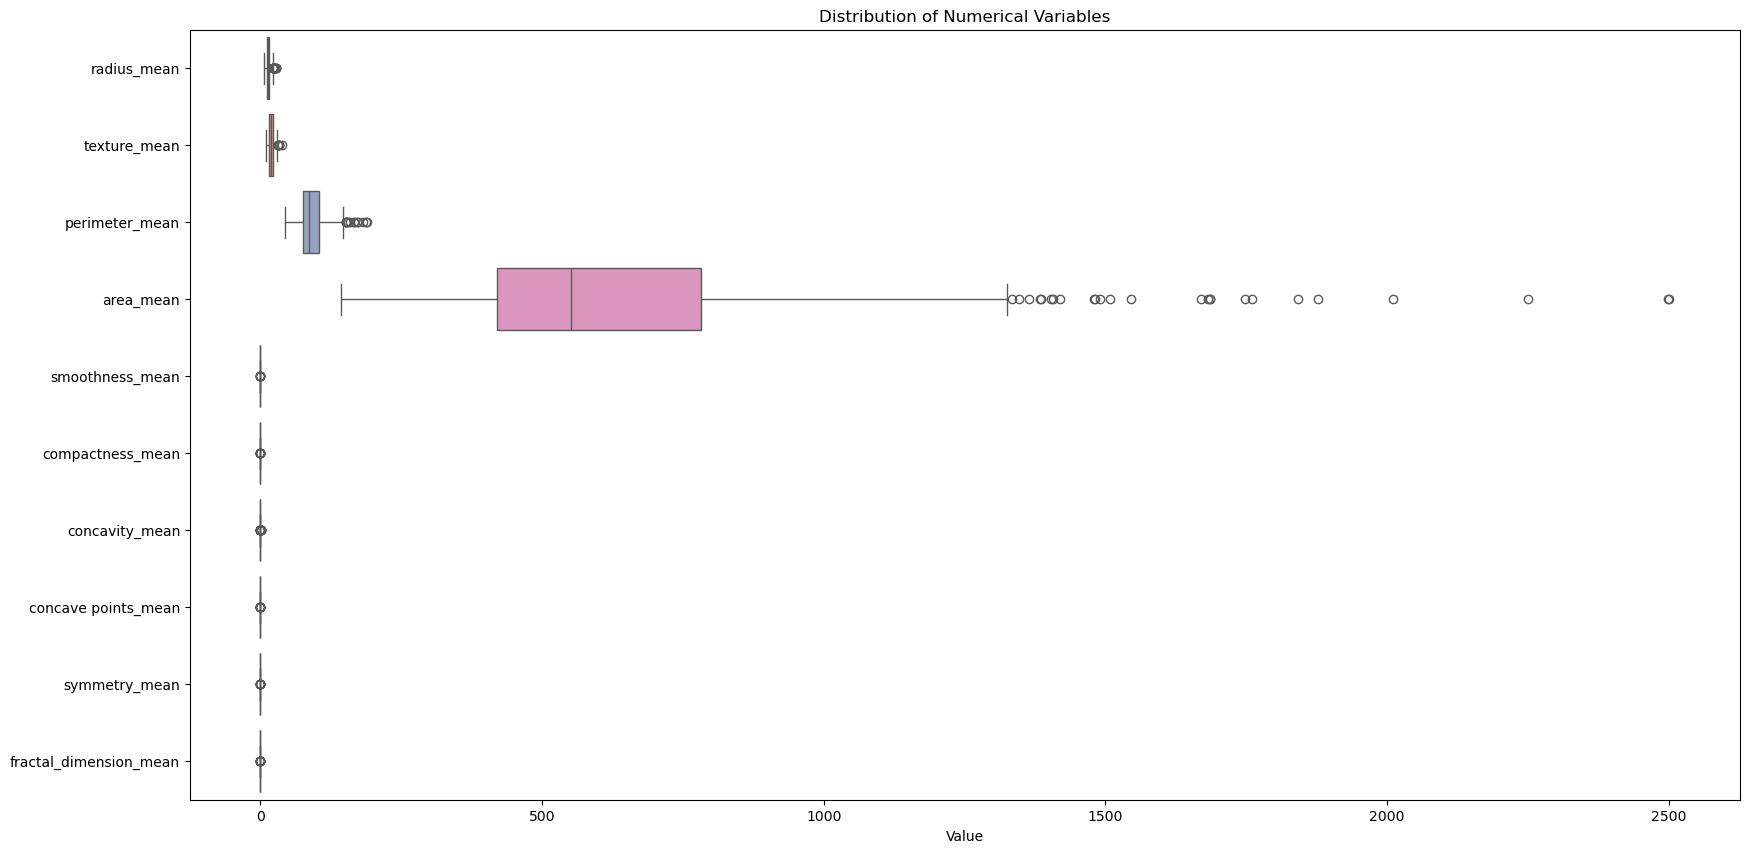

In [17]:
numerical_cols = ['radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean',
       'concavity_mean', 'concave points_mean', 'symmetry_mean',
       'fractal_dimension_mean']
# numerical_cols: Selects numerical columns from the dataset: Age, Driving_License, Region_Code, Previously_Insured, Policy_Sales_Channel, Vintage, and Response.

plt.figure(figsize=(20, 10))
sns.boxplot(data=data[numerical_cols], orient='h', palette='Set2')
# sns.boxplot(): Plots the box plot for the selected numerical columns.
# orient='h': Displays the boxes horizontally.
# palette='Set2': Applies a soft color palette.

plt.title('Distribution of Numerical Variables')
plt.xlabel('Value')
plt.show()

### 5. Data Preprocessing

In [18]:
data['diagnosis'].value_counts()   # counts of unique rows in the 'diagnosis' column
data['diagnosis']=data['diagnosis'].map({'B':0,'M':1})   # mapping categorical values to numerical values
data['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [19]:
X=data.drop('diagnosis', axis=1)
y=data["diagnosis"]

In [20]:
from sklearn.model_selection import train_test_split
# splitting data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
#x: Features (input data) , y: Target variable (output).
# test_size=0.2: 20% of the data is used for testing, and 80% for training.
# random_state=101: Ensures reproducibility of the split.
X_train.shape,X_test.shape
# Displays the shape (rows and columns) of the training and testing feature sets.

((455, 30), (114, 30))

### 6.Classification Models

### 
- Logistic Regression

In [21]:
#  imports the Logistic Regression model from scikit-learn.
from sklearn.linear_model import LogisticRegression

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)
#x: Features (input data) , y: Target variable (output).
# test_size=0.2: 20% of the data is used for testing, and 80% for training.
# random_state=101: Ensures reproducibility of the split.

X_train.shape,X_test.shape
# Displays the shape (rows and columns) of the training and testing feature sets.

((455, 30), (114, 30))

In [23]:
# Trains a Logistic Regression model:
model=LogisticRegression()
model.fit(X_train,y_train)
# Fits the model to the training data.


LogisticRegression()

In [24]:
from sklearn import metrics

In [25]:
prediction_test=model.predict(X_test)
# Predicts the target values for the test set (x_test).

print(metrics.accuracy_score(y_test,prediction_test))
# metrics.accuracy_score(y_test, prediction_test)=Compares the true values (y_test) with the predicted values (prediction_test) and calculates the accuracy of the model.

0.9473684210526315


In [26]:
preds = model.predict(X_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,preds))
# Compares the true values (y_test) with the predicted values (preds) and generates a confusion matrix.


[[69  3]
 [ 3 39]]


In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))
# prints the classification report for the Logistic Regression model's predictions

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        72
           1       0.93      0.93      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



###
- Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
# train_test_split(x, y, test_size=0.2, random_state=101):Splits the dataset into 80% training and 20% testing.

model_rf = RandomForestClassifier(n_estimators=1000, oob_score=True, n_jobs=-1, random_state=101, max_leaf_nodes=30)
# Initializes a Random Forest Classifier with 1000 trees, out-of-bag scoring (oob_score=True), parallel computation (n_jobs=-1),and a maximum of 30 leaf nodes per tree.

model_rf.fit(X_train, y_train)
# Trains the Random Forest model on the training dat


# Make predictions

prediction_test = model_rf.predict(X_test)
# prediction_test = model_rf.predict(x_test):Predicts the target values for the test set.

print(metrics.accuracy_score(y_test, prediction_test))
# metrics.accuracy_score(y_test, prediction_test):Calculates and prints the accuracy score of the model.

0.9736842105263158


In [29]:
print(confusion_matrix(y_test,preds))
# Compares the true values (y_test) with the predicted values (preds) and generates a confusion matrix.


[[69  3]
 [ 3 39]]


In [30]:
print(classification_report(y_test, preds))
# prints the classification report for the Random Forest model's predictions

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        72
           1       0.93      0.93      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



###
- Support Vector Machine

In [31]:
from sklearn.svm import SVC
model_svm = SVC()
# Initializes the SVM model with default parameters.

model_svm.fit(X_train,y_train)
# Trains the SVM model on the training data (x_train for features and y_train for the target).

#preds = model.svm.predict(x_test)
#metrics.accuracy_score(y_test, preds)

SVC()

In [32]:
preds = model_svm.predict(X_test)
# Makes predictions using the trained SVM model on the test data (x_test)

metrics.accuracy_score(y_test, preds)
# Compares the true values (y_test) with the predicted values (preds) and calculates the accuracy of the modela.

0.9473684210526315

In [33]:
print(confusion_matrix(y_test,preds))
# Compares the true values (y_test) with the predicted values (preds) and generates a confusion matrix.

# The confusion matrix shows:
#      -  TN (True Negatives): Correctly predicted negative class.
#      -  FP (False Positives): Incorrectly predicted positive class.
#      -  FN (False Negatives): Incorrectly predicted negative class.
#      -  TP (True Positives): Correctly predicted positive class.

[[72  0]
 [ 6 36]]


In [34]:
print(classification_report(y_test, preds))
# prints the classification report for the SVM model's predictions

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        72
           1       1.00      0.86      0.92        42

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



###
- ADA Boost

In [35]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()

model.fit(X_train,y_train)
# Trains the AdaBoost model on the training data.

preds = model.predict(X_test)
# Makes predictions on the test data.

metrics.accuracy_score(y_test, preds)
# Compares the true values (y_test) with the predicted values (preds) and prints the accuracy score.

0.9736842105263158

In [36]:
print(classification_report(y_test, preds))
# prints the classification report for the AdaBoost model's predictionn

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [37]:
print(confusion_matrix(y_test,preds))
# prints the confusion matrix for the AdaBoost model's predictions

[[72  0]
 [ 3 39]]


### 
- XGB Classifier

In [38]:
from xgboost import XGBClassifier
model = XGBClassifier()
# Initializes the XGBoost model with default parameters.

model.fit(X_train, y_train)
# Trains the XGBoost model on the training data.

preds = model.predict(X_test)
# Makes predictions on the test data.

metrics.accuracy_score(y_test, preds)
# Compares the true values (y_test) with the predicted values (preds) and calculates the accuracy.

0.9824561403508771

In [39]:
print(classification_report(y_test, preds))
# prints the classification report for the XGBoost model's predictions

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [40]:
print(confusion_matrix(y_test,preds))
# prints the confusion matrix for the XGBoost model's predictions

[[72  0]
 [ 2 40]]


###
- KNeighbor Classifier

In [41]:
from sklearn.neighbors import KNeighborsClassifier
error_rate = []

for i in range(1,42):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

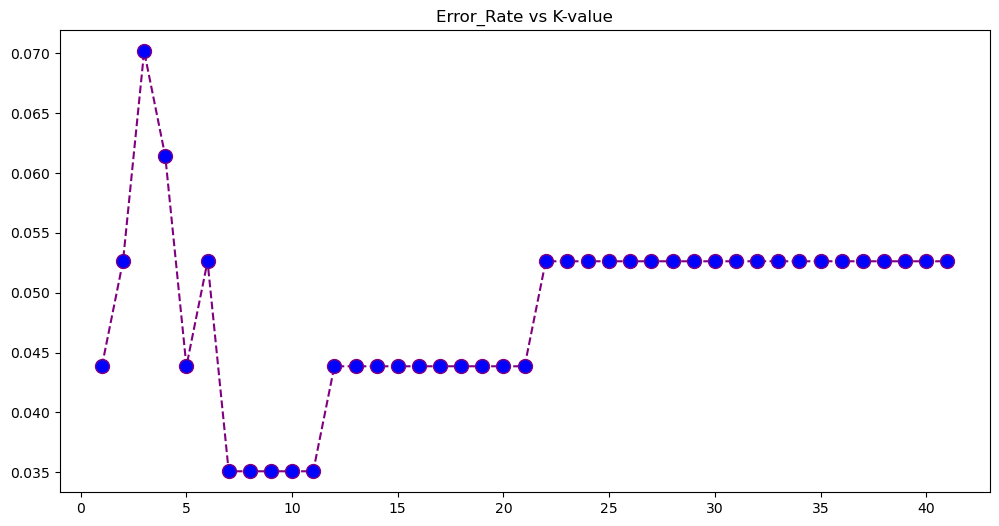

In [42]:
plt.figure(figsize=(12,6))
plt.plot(range(1,42), error_rate, color='purple', linestyle="--",
         marker='o', markersize=10, markerfacecolor='b')
plt.title('Error_Rate vs K-value')
plt.show()

In [43]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
predictions2 = knn.predict(X_test)

In [44]:
print(confusion_matrix(y_test, predictions2))
print("\n")
print(classification_report(y_test, predictions2))

[[72  0]
 [ 4 38]]


              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



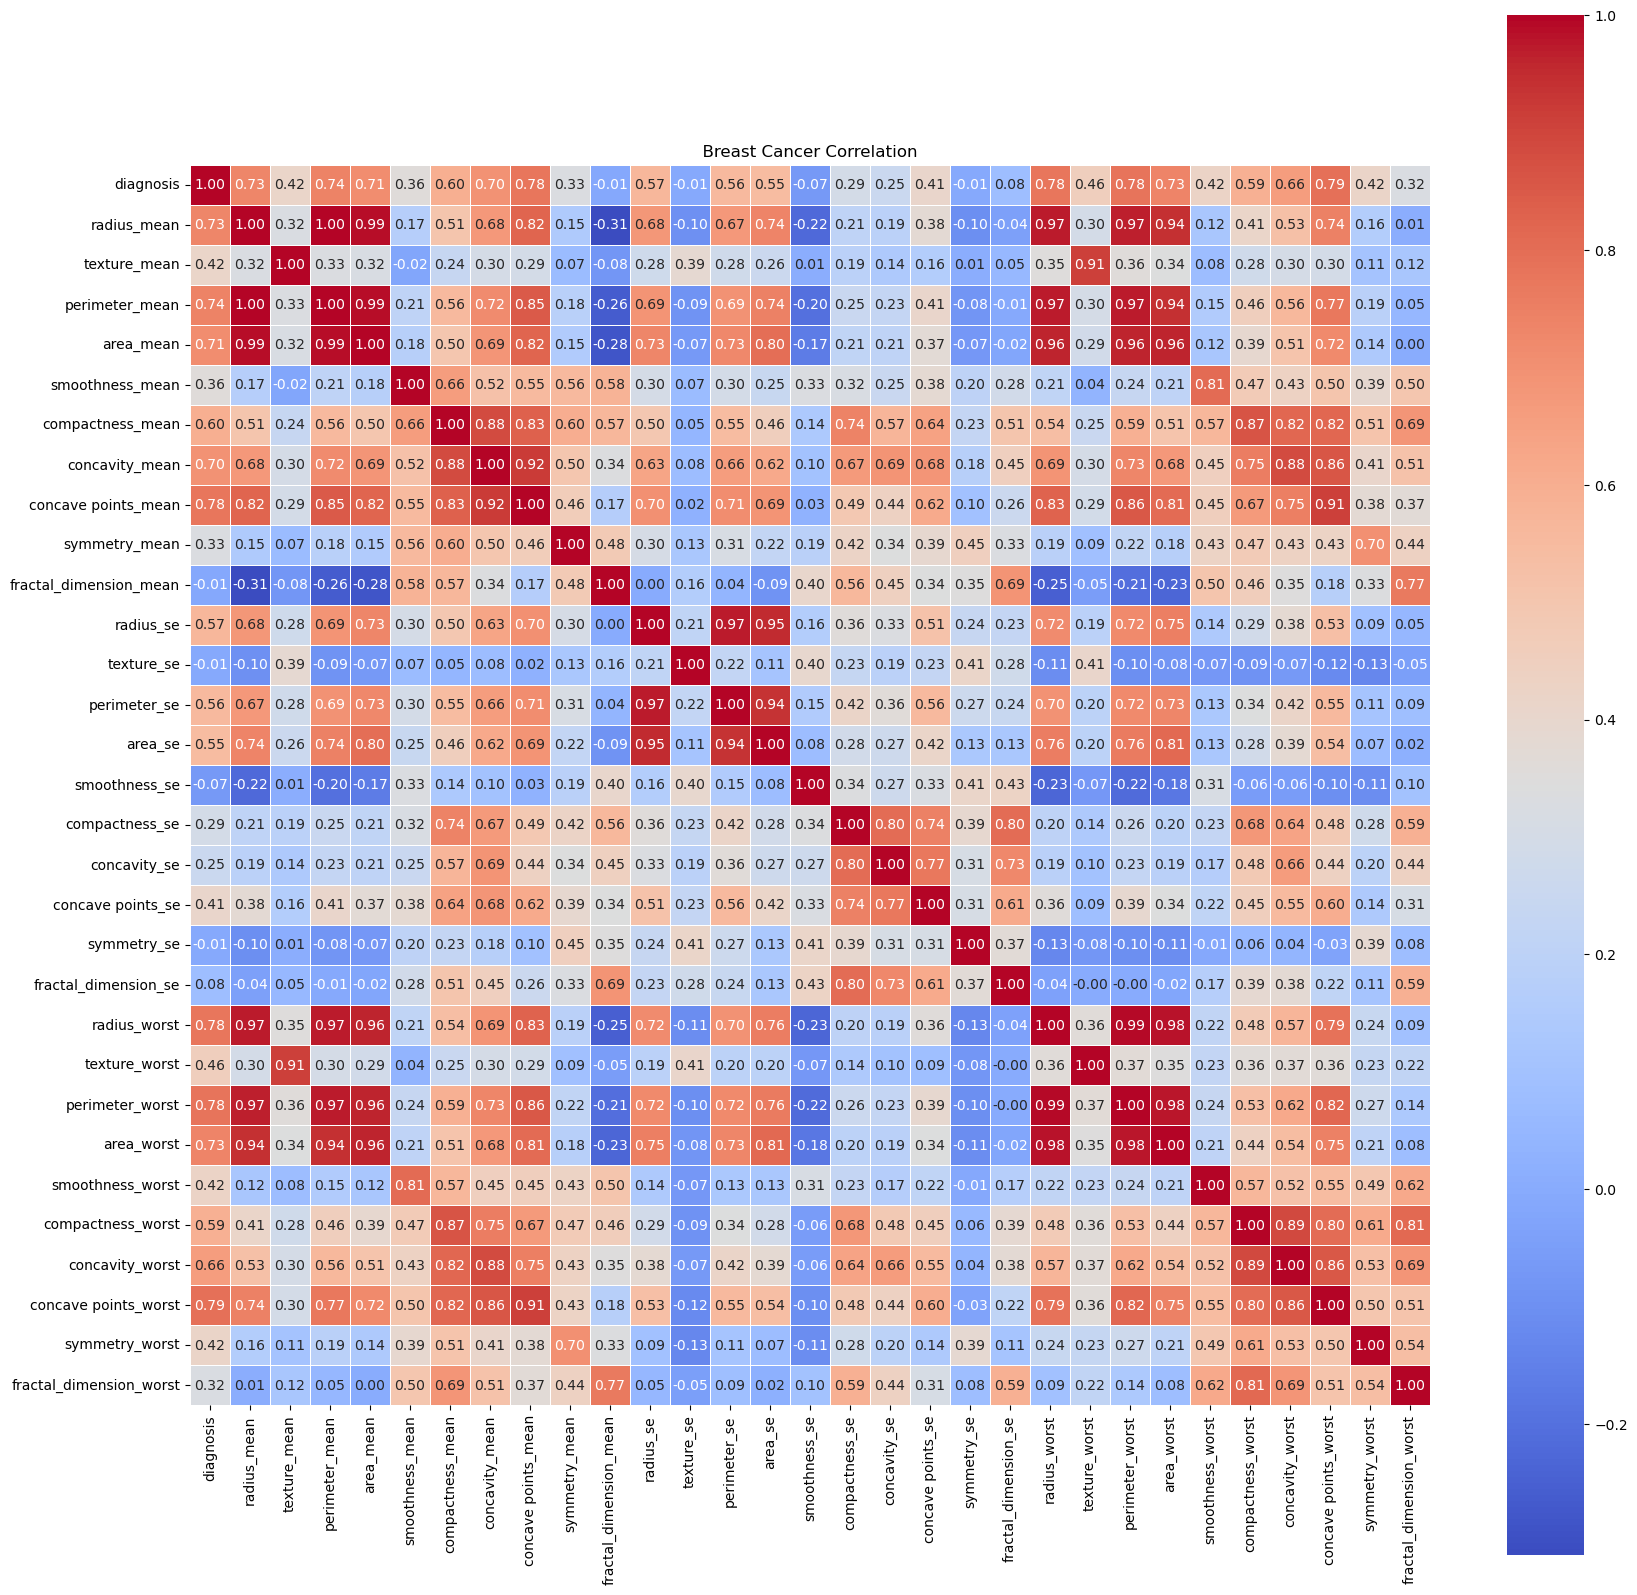

In [45]:
from sklearn.preprocessing import LabelEncoder

# Encode non-numerical columns
non_numeric_columns = data.select_dtypes(exclude=['number']).columns

le = LabelEncoder()
for col in non_numeric_columns:
    data[col] = le.fit_transform(data[col].astype(str))

# Handle missing values
data = data.dropna()

# Now compute the correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('  Breast Cancer Correlation  ')
plt.show()

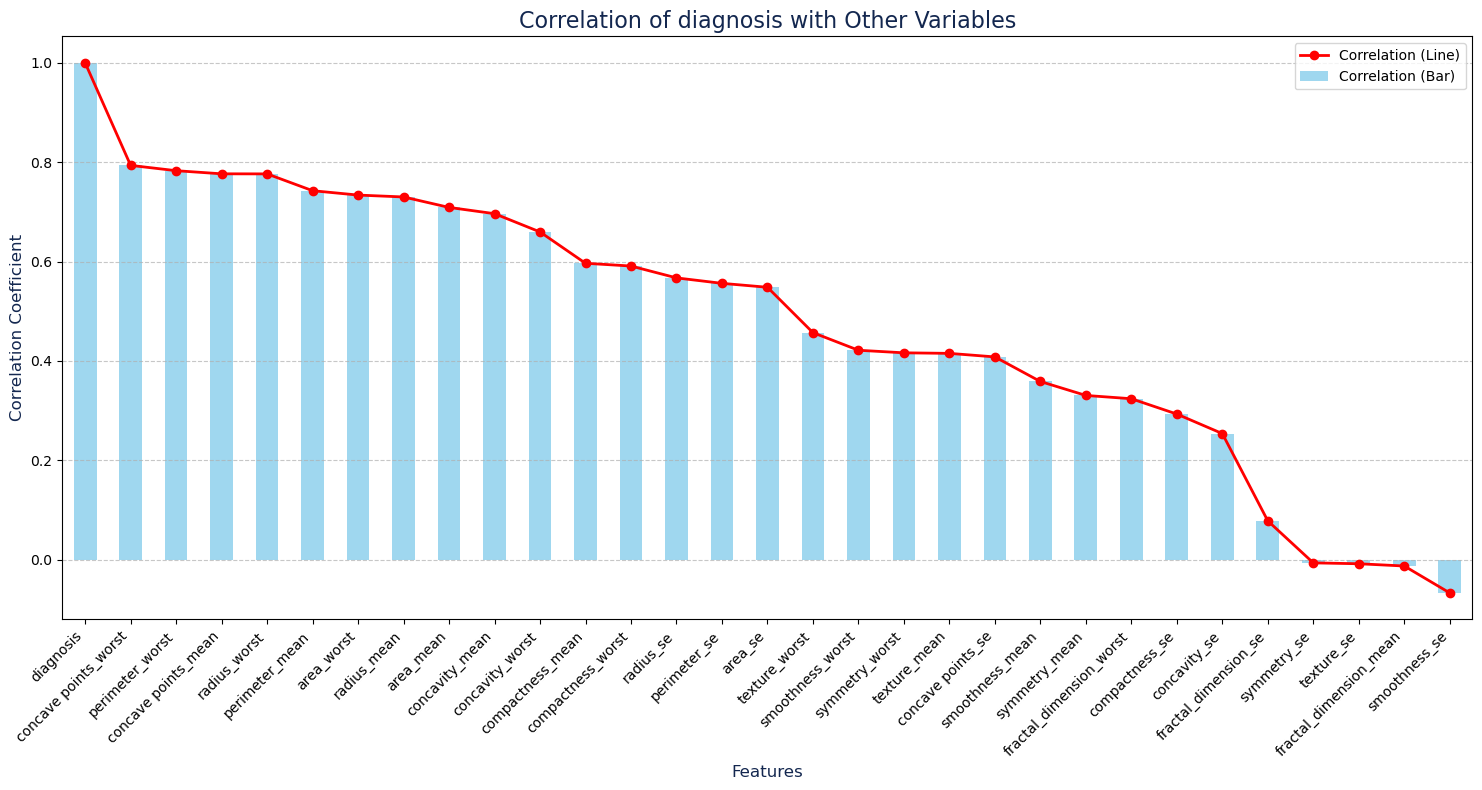

In [46]:
# Compute correlations
correlations = data.corr()['diagnosis'].sort_values(ascending=False)

# Create the figure
plt.figure(figsize=(15, 8))

# Plot the bar chart
correlations.plot(kind='bar', color='skyblue', alpha=0.8, label='Correlation (Bar)')

# Overlay a line plot
plt.plot(correlations.index, correlations.values, color='red', marker='o', linewidth=2, label='Correlation (Line)')

# Add title and labels
plt.title('Correlation of diagnosis with Other Variables', fontsize=16, color='#13274F')
plt.xlabel('Features', fontsize=12, color='#13274F')
plt.ylabel('Correlation Coefficient', fontsize=12, color='#13274F')

# Add legend
plt.legend(fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()